In [ ]:
# Step 0: Understand what the data looks like
import os
import pandas as pd

# Change this to your local repository root
REPO = "."  # e.g. "/Users/you/SPHERE-PPL-Forecasting-Contest"

# List files in the data folder
for root, dirs, files in os.walk(os.path.join(REPO, "data")):
    for f in files:
        path = os.path.join(root, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f"{path}  ({size_mb:.1f} MB)")

./data/.DS_Store  (0.0 MB)
./data/turingAI_forecasting_challenge_dataset.csv.zip  (86.5 MB)
./data/metric_metadata.csv  (0.0 MB)
./data/metric_details.xlsx  (0.0 MB)


In [ ]:
# Step 1: Load the data and inspect the basic structure
import pandas as pd

# Change the path to the main data file identified above
DATA_PATH = "./data/turingAI_forecasting_challenge_dataset.csv.zip"  # Change to the actual path

df = pd.read_csv(DATA_PATH, parse_dates=True)  # Use pd.read_parquet for parquet files

print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn dtypes (first 30):")
print(df.dtypes.head(30))
print("\nColumn names (all):")
print(list(df.columns))

Shape: (16728656, 6)

First 3 rows:
                    dt                    metric_name  \
0  2023-03-16 13:00:00                Patients in A&E   
1  2023-03-16 13:00:00         4hr Breach Performance   
2  2023-03-16 13:00:00  Total Breaches Since Midnight   

                  coverage  value coverage_label variable_type  
0  Bristol Royal Infirmary   35.0            BRI       feature  
1  Bristol Royal Infirmary   83.0            BRI       feature  
2  Bristol Royal Infirmary   10.0            BRI       feature  

Column dtypes (前 30 个):
dt                    str
metric_name           str
coverage              str
value             float64
coverage_label        str
variable_type         str
dtype: object

Column names (全部):
['dt', 'metric_name', 'coverage', 'value', 'coverage_label', 'variable_type']


In [ ]:
# Inspect the distribution of variable_type and metric
print("variable_type distribution:")
print(df["variable_type"].value_counts())

print("\nNumber of metric_name values:", df["metric_name"].nunique())
print("Number of coverage values:", df["coverage"].nunique())

# metric x coverage combinations = number of candidate variables
combos = df.groupby(["variable_type", "metric_name", "coverage"]).size().reset_index(name="n_rows")
print("\nNumber of combinations by variable_type:")
print(combos.groupby("variable_type").size())

# Inspect what the target is
print("\n--- TARGET-related ---")
print(combos[combos["variable_type"] == "target"])

# Inspect the top 20 feature combinations by row count to see which variables are high-frequency
print("\n--- FEATURE combinations: top 20 by row count ---")
print(combos[combos["variable_type"] == "feature"].sort_values("n_rows", ascending=False).head(20))

# Inspect the bottom 20 feature combinations by row count to see low-frequency or sparse variables
print("\n--- FEATURE combinations: bottom 20 by row count ---")
print(combos[combos["variable_type"] == "feature"].sort_values("n_rows", ascending=False).tail(20))

variable_type 分布:
variable_type
feature    16710350
outcome       18306
Name: count, dtype: int64

metric_name 总数: 221
coverage 总数: 35

按 variable_type 分的组合数:
variable_type
feature    559
outcome      1
dtype: int64

--- TARGET 相关 ---
Empty DataFrame
Columns: [variable_type, metric_name, coverage, n_rows]
Index: []

--- FEATURE 组合，按行数排序前 20 ---
    variable_type                                       metric_name  \
56        feature       Ambulance Handovers 60mins (Since Midnight)   
48        feature       Ambulance Handovers 30mins (Since Midnight)   
71        feature                   Ambulances En Route to Hospital   
36        feature            Ambulance Handovers 15mins (Last Hour)   
67        feature  Ambulances Conveyed to Hospital (Since Midnight)   
40        feature       Ambulance Handovers 15mins (Since Midnight)   
262       feature         Handover to Clear 30mins (Since Midnight)   
63        feature       Ambulances Conveyed to Hospital (Last Hour)   
44        feat

In [ ]:
df["dt"] = pd.to_datetime(df["dt"], format="ISO8601")

print("Time range:", df["dt"].min(), "->", df["dt"].max())

# Inspect the temporal resolution for each metric_name using the median gap between adjacent timestamps
sample_metrics = df["metric_name"].unique()[:10]
for m in sample_metrics:
    sub = df[df["metric_name"] == m].sort_values("dt")["dt"].drop_duplicates()
    if len(sub) > 1:
        median_gap = sub.diff().median()
        print(f"{m}: n_timepoints={len(sub)}, median gap={median_gap}")

时间范围: 2023-03-16 00:00:00 -> 2026-03-30 00:00:00
Patients in A&E: n_timepoints=102359, median gap=0 days 00:15:00
4hr Breach Performance: n_timepoints=102264, median gap=0 days 00:15:00
Total Breaches Since Midnight: n_timepoints=102180, median gap=0 days 00:15:00
No. of DTAs: n_timepoints=102359, median gap=0 days 00:15:00
Average Time to Triage: n_timepoints=102336, median gap=0 days 00:15:00
Average Time to Assessment: n_timepoints=102303, median gap=0 days 00:15:00
New Arrivals in Last Hour: n_timepoints=102352, median gap=0 days 00:15:00
Resuscitation Capacity: n_timepoints=102359, median gap=0 days 00:15:00
A&E Discharges in Last Hour: n_timepoints=102353, median gap=0 days 00:15:00
Minors patient count: n_timepoints=102271, median gap=0 days 00:15:00
Cohorting & Reverse Queue: n_timepoints=102294, median gap=0 days 00:15:00
No. of DTAs (> 8hrs): n_timepoints=102028, median gap=0 days 00:15:00
Majors patient count: n_timepoints=102081, median gap=0 days 00:15:00
Ambulance Queue: 

In [ ]:
# Step 3: What does the outcome variable look like?
out = df[df["variable_type"] == "outcome"].copy()

print("Outcome shape:", out.shape)
print("\nMetric/coverage:")
print(out[["metric_name", "coverage", "coverage_label"]].drop_duplicates())

print("\nTime range:", out["dt"].min(), "->", out["dt"].max())

# Inspect timestamp resolution
gaps = out["dt"].sort_values().diff().dropna()
print("\nTime gap statistics:")
print(gaps.describe())
print("\nMost common gaps (top 5):")
print(gaps.value_counts().head())

# Inspect the basic distribution of value, especially whether there are -9999 dummy values
print("\nValue summary statistics:")
print(out["value"].describe())
print("\nCount of -9999:", (out["value"] == -9999).sum())
print("Summary statistics excluding -9999:")
print(out.loc[out["value"] != -9999, "value"].describe())

# Check whether -9999 appears only in the evaluation period
dummy = out[out["value"] == -9999]
real = out[out["value"] != -9999]
if len(dummy) > 0:
    print(f"\nTime range of -9999: {dummy['dt'].min()} -> {dummy['dt'].max()}")
print(f"Time range of non-dummy values: {real['dt'].min()} -> {real['dt'].max()}")

Outcome shape: (18306, 6)

Metric/coverage:
                         metric_name  \
12887630  estimated_avoidable_deaths   

                                                   coverage coverage_label  
12887630  NHS Bristol, North Somerset, South Gloucesters...          BNSSG  

时间范围: 2023-03-16 00:00:00 -> 2026-03-30 00:00:00

时间间隔统计:
count                     18305
mean     0 days 01:27:19.224255
std      0 days 05:12:46.833697
min             0 days 00:15:00
25%             0 days 00:15:00
50%             0 days 00:15:00
75%             0 days 00:15:00
max             1 days 00:00:00
Name: dt, dtype: object

最常见的间隔（前 5）:
dt
0 days 00:15:00    17376
1 days 00:00:00      929
Name: count, dtype: int64

Value 描述统计:
count    18306.000000
mean     -9490.986606
std       2195.939928
min      -9999.000000
25%      -9999.000000
50%      -9999.000000
75%      -9999.000000
max          2.203913
Name: value, dtype: float64

-9999 出现次数: 17376
非 -9999 的描述统计:
count    930.000000
mean       0.67010

In [ ]:
import numpy as np

# Extract the real outcome and convert it to daily frequency
y = (df[(df["variable_type"] == "outcome") & (df["value"] != -9999)]
     .assign(date=lambda d: d["dt"].dt.normalize())
     .set_index("date")["value"]
     .sort_index())

print("y shape:", y.shape)
print("Date range:", y.index.min(), "->", y.index.max())

# Check whether there is exactly one value per day
n_per_day = y.groupby(y.index).size()
print("Distribution of values per day:", n_per_day.value_counts().to_dict())

# Check continuity (whether any dates are skipped)
expected = pd.date_range(y.index.min(), y.index.max(), freq="D")
missing_dates = expected.difference(y.index)
print("Number of missing dates:", len(missing_dates))
if len(missing_dates) > 0:
    print("Missing dates:", list(missing_dates)[:10])

# Save to CSV for reuse so later steps do not need repeated processing
y.to_csv("outcome_daily.csv")
print("\nSaved outcome_daily.csv")

y shape: (930,)
日期范围: 2023-03-16 00:00:00 -> 2025-09-30 00:00:00
每天值的数量分布: {1: 930}
缺失日期数: 0

已保存 outcome_daily.csv


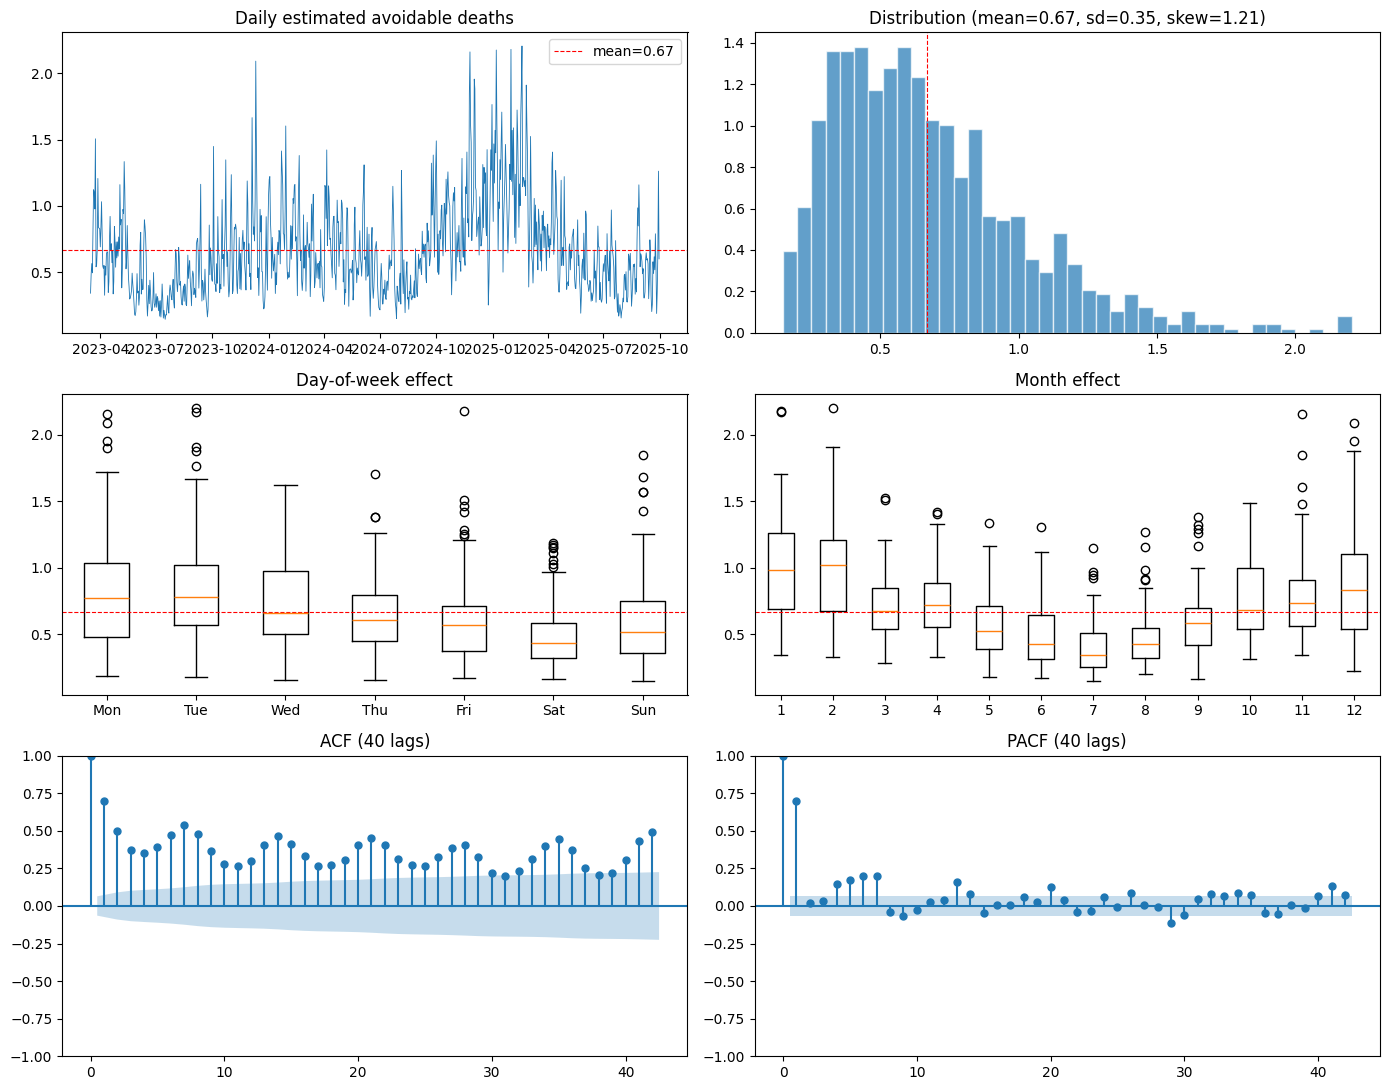

已保存 outcome_eda.png

--- 关键统计 ---
n              = 930
mean           = 0.6701
std            = 0.3489
var            = 0.1217
var/mean       = 0.1817  (Poisson 应≈1)
skewness       = 1.2061
kurtosis       = 1.9096
p90, p95, p99  = [1.1519685  1.32387439 1.82309612]


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(14, 11))

# (1) Time series
axes[0,0].plot(y.index, y.values, lw=0.6)
axes[0,0].set_title("Daily estimated avoidable deaths")
axes[0,0].axhline(y.mean(), color="red", ls="--", lw=0.8, label=f"mean={y.mean():.2f}")
axes[0,0].legend()

# (2) Histogram + KDE
axes[0,1].hist(y, bins=40, density=True, alpha=0.7, edgecolor="white")
axes[0,1].axvline(y.mean(), color="red", ls="--", lw=0.8)
axes[0,1].set_title(f"Distribution (mean={y.mean():.2f}, sd={y.std():.2f}, skew={y.skew():.2f})")

# (3) Day-of-week effect (boxplot)
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
by_dow = [y[y.index.dayofweek == i].values for i in range(7)]
axes[1,0].boxplot(by_dow, tick_labels=dow_labels)
axes[1,0].set_title("Day-of-week effect")
axes[1,0].axhline(y.mean(), color="red", ls="--", lw=0.8)

# (4) Month effect
by_month = [y[y.index.month == i].values for i in range(1, 13)]
axes[1,1].boxplot(by_month, tick_labels=range(1,13))
axes[1,1].set_title("Month effect")
axes[1,1].axhline(y.mean(), color="red", ls="--", lw=0.8)

# (5) ACF
plot_acf(y, lags=42, ax=axes[2,0])
axes[2,0].set_title("ACF (40 lags)")

# (6) PACF
plot_pacf(y, lags=42, ax=axes[2,1], method="ywm")
axes[2,1].set_title("PACF (40 lags)")

plt.tight_layout()
plt.savefig("outcome_eda.png", dpi=120)
plt.show()
print("Saved outcome_eda.png")

# Print key statistics
print("\n--- Key statistics ---")
print(f"n              = {len(y)}")
print(f"mean           = {y.mean():.4f}")
print(f"std            = {y.std():.4f}")
print(f"var            = {y.var():.4f}")
print(f"var/mean       = {y.var()/y.mean():.4f}  (Poisson should be approx. 1)")
print(f"skewness       = {y.skew():.4f}")
print(f"kurtosis       = {y.kurt():.4f}")
print(f"p90, p95, p99  = {y.quantile([0.9, 0.95, 0.99]).values}")

原始 y std: 0.3489238836910741
month×dow 残差 std: 0.25652773979513777
解释方差比例: 0.4594855933695754


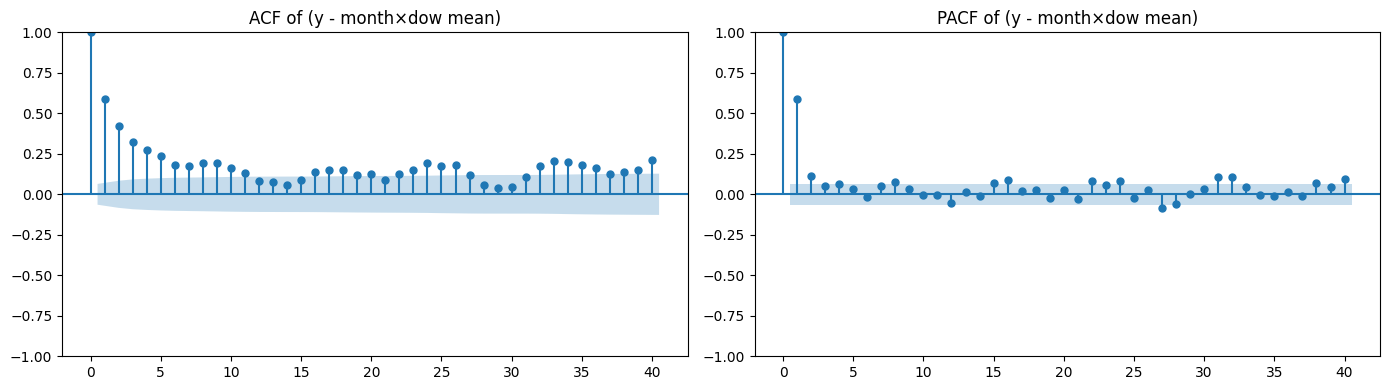


冬季 mean=0.970, std=0.424, n=181
夏季 mean=0.450, std=0.215, n=276
std 比例: 1.98


In [ ]:
# (A) Inspect ACF/PACF of residuals after subtracting the month x DoW mean
# This shows how much true "non-seasonal" autoregression remains
mu_table = y.groupby([y.index.month, y.index.dayofweek]).mean()
def lookup(d):
    return mu_table.loc[(d.month, d.dayofweek)]
seasonal_pred = pd.Series(y.index.map(lookup), index=y.index)
resid = y - seasonal_pred

print("Raw y std:", y.std())
print("month x dow residual std:", resid.std())
print("Explained variance share:", 1 - resid.var()/y.var())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid, lags=40, ax=axes[0])
axes[0].set_title("ACF of (y - month x dow mean)")
plot_pacf(resid, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of (y - month x dow mean)")
plt.tight_layout()
plt.savefig("resid_acf.png", dpi=120)
plt.show()

# (B) Heteroskedasticity: winter variance vs summer variance
winter = y[y.index.month.isin([12, 1, 2])]
summer = y[y.index.month.isin([6, 7, 8])]
print(f"\nWinter mean={winter.mean():.3f}, std={winter.std():.3f}, n={len(winter)}")
print(f"Summer mean={summer.mean():.3f}, std={summer.std():.3f}, n={len(summer)}")
print(f"Std ratio: {winter.std()/summer.std():.2f}")

In [ ]:
import pandas as pd
import numpy as np

# === Load data ===
y = pd.read_csv("outcome_daily.csv", index_col=0, parse_dates=True).squeeze("columns")
y.name = "y"

# === Time split ===
TRAIN_END = pd.Timestamp("2024-09-30")
EVAL_START = pd.Timestamp("2024-10-01")
EVAL_END = pd.Timestamp("2025-09-30")

y_train = y.loc[:TRAIN_END]
y_eval = y.loc[EVAL_START:EVAL_END]

print(f"Training set: {y_train.index.min().date()} -> {y_train.index.max().date()}, n={len(y_train)}")
print(f"Pseudo-evaluation period: {y_eval.index.min().date()} -> {y_eval.index.max().date()}, n={len(y_eval)}")

# === Rolling-window list of D values ===
# D is "today", and we forecast D+1 to D+10
# First D = 2024-09-30, forecasting 10-01 to 10-10
# Last D = 2025-09-20, forecasting 9-21 to 9-30
D_list = pd.date_range("2024-09-30", "2025-09-20", freq="D")
print(f"Number of rolling windows: {len(D_list)}")


# === Evaluation function ===
def make_available_y(y_full, D):
    """Simulate the y available by midday on day D: due to the three-day lag, only up to D-3 is available."""
    return y_full.loc[: D - pd.Timedelta(days=3)]


def evaluate_forecaster(forecaster_fn, D_list, y_full, name=""):
    """
    forecaster_fn(D, available_y) -> array of length 10 for forecasts D+1 ... D+10
    returns (mse_1to5d, mse_6to10d)
    """
    sq_err_15, sq_err_610 = [], []

    for D in D_list:
        avail = make_available_y(y_full, D)
        preds = forecaster_fn(D, avail)
        assert len(preds) == 10, f"Forecast length must be 10, got {len(preds)}"

        for h in range(1, 11):
            target_date = D + pd.Timedelta(days=h)
            if target_date in y_full.index:
                err = (y_full.loc[target_date] - preds[h - 1]) ** 2
                (sq_err_15 if h <= 5 else sq_err_610).append(err)

    mse_15 = np.mean(sq_err_15)
    mse_610 = np.mean(sq_err_610)
    print(f"{name:35s}  MSE_1to5d = {mse_15:.4f}   MSE_6to10d = {mse_610:.4f}")
    return mse_15, mse_610


# === Baseline 1: constant (training-set mean) ===
TRAIN_MEAN = y_train.mean()

def fc_constant(D, available_y):
    return np.full(10, TRAIN_MEAN)


# === Baseline 2: month x DoW lookup table (training set only) ===
MXD_TABLE = y_train.groupby([y_train.index.month, y_train.index.dayofweek]).mean()

def fc_month_dow(D, available_y):
    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        out[h - 1] = MXD_TABLE.loc[(d.month, d.dayofweek)]
    return out


# === Baseline 3: same DoW last week (seasonal naive under the three-day lag constraint) ===
def fc_last_same_dow(D, available_y):
    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        cand = available_y[available_y.index.dayofweek == d.dayofweek]
        out[h - 1] = cand.iloc[-1] if len(cand) > 0 else TRAIN_MEAN
    return out


# === Baseline 4: mean of the same DoW over the last 4 weeks (smoothed seasonal naive) ===
def fc_last_4w_dow(D, available_y):
    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        cand = available_y[available_y.index.dayofweek == d.dayofweek].iloc[-4:]
        out[h - 1] = cand.mean() if len(cand) > 0 else TRAIN_MEAN
    return out


# === Baseline 5: month x DoW + recent residual drift calibration ===
# Use the month x DoW table as the main forecast, then add the mean residual over the last week of available y as a drift correction
def fc_mxd_drift(D, available_y):
    # Compute residuals = actual - month x DoW table over the most recent 14 available days
    recent = available_y.iloc[-14:]
    if len(recent) == 0:
        drift = 0.0
    else:
        recent_mxd = pd.Series(
            [MXD_TABLE.loc[(d.month, d.dayofweek)] for d in recent.index],
            index=recent.index,
        )
        drift = (recent - recent_mxd).mean()

    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        out[h - 1] = MXD_TABLE.loc[(d.month, d.dayofweek)] + drift
    return out


# === Run all baselines ===
print("\n=== Baseline results ===")
results = {}
for name, fn in [
    ("Constant (train mean)", fc_constant),
    ("Month x DoW", fc_month_dow),
    ("Last same DoW", fc_last_same_dow),
    ("Last 4-wk same DoW mean", fc_last_4w_dow),
    ("Month x DoW + drift", fc_mxd_drift),
]:
    results[name] = evaluate_forecaster(fn, D_list, y, name)

# === Also compare against the lower bound for "perfect seasonality": use the same DoW mean from the full y as a reference ===
# This is not a valid forecaster because it uses future data; it is only a rough reference for the predictability ceiling
ORACLE_MXD = y.groupby([y.index.month, y.index.dayofweek]).mean()
def fc_oracle_mxd(D, available_y):
    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        out[h - 1] = ORACLE_MXD.loc[(d.month, d.dayofweek)]
    return out

print("\n=== Reference line (invalid forecaster, ceiling only) ===")
evaluate_forecaster(fc_oracle_mxd, D_list, y, "ORACLE Month x DoW (full y)")

训练集: 2023-03-16 -> 2024-09-30, n=565
伪评估期: 2024-10-01 -> 2025-09-30, n=365
滚动窗口数: 356

=== 基线结果 ===
Constant (train mean)                MSE_1to5d = 0.1978   MSE_6to10d = 0.1980
Month x DoW                          MSE_1to5d = 0.1318   MSE_6to10d = 0.1319
Last same DoW                        MSE_1to5d = 0.1358   MSE_6to10d = 0.1574
Last 4-wk same DoW mean              MSE_1to5d = 0.1073   MSE_6to10d = 0.1124
Month x DoW + drift                  MSE_1to5d = 0.0940   MSE_6to10d = 0.1061

=== 参考线（不合法，仅供参考天花板）===
ORACLE Month x DoW (全 y)             MSE_1to5d = 0.0754   MSE_6to10d = 0.0756


(np.float64(0.07537921542259428), np.float64(0.07555084638968762))

      train_2023-24  eval_2024-25
date                             
1          0.814576      1.221050
2          0.728605      1.304584
3          0.666471      0.772811
4          0.719791      0.807610
5          0.582395      0.556964
6          0.500328      0.476063
7          0.368309      0.459309
8          0.431870      0.517579
9          0.617237      0.524479
10         0.623778      0.881540
11         0.659935      0.937731
12         0.731745      1.036121

月均差 (eval - train):
date
1     0.406
2     0.576
3     0.106
4     0.088
5    -0.025
6    -0.024
7     0.091
8     0.086
9    -0.093
10    0.258
11    0.278
12    0.304
dtype: float64

训练集总均值: 0.594
伪评估期总均值: 0.788


/var/folders/ht/grsh5psd3yvbf02wwj5dsrg40000gp/T/ipykernel_89784/2345244448.py:21: UserWarning: Glyph 20266 (\N{CJK UNIFIED IDEOGRAPH-4F2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/grsh5psd3yvbf02wwj5dsrg40000gp/T/ipykernel_89784/2345244448.py:21: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/grsh5psd3yvbf02wwj5dsrg40000gp/T/ipykernel_89784/2345244448.py:21: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/grsh5psd3yvbf02wwj5dsrg40000gp/T/ipykernel_89784/2345244448.py:21: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ht/grsh5psd3yvbf02wwj5dsrg40000gp/T/ipykernel_89784/2345244448.py:22: UserWarning: Glyph 20266 (\N{CJK UNIFIED IDEOGRAPH-4F2A}) missing from font(s) DejaVu Sans.
  plt.savefig("y_rolling.png", dpi=120)
/

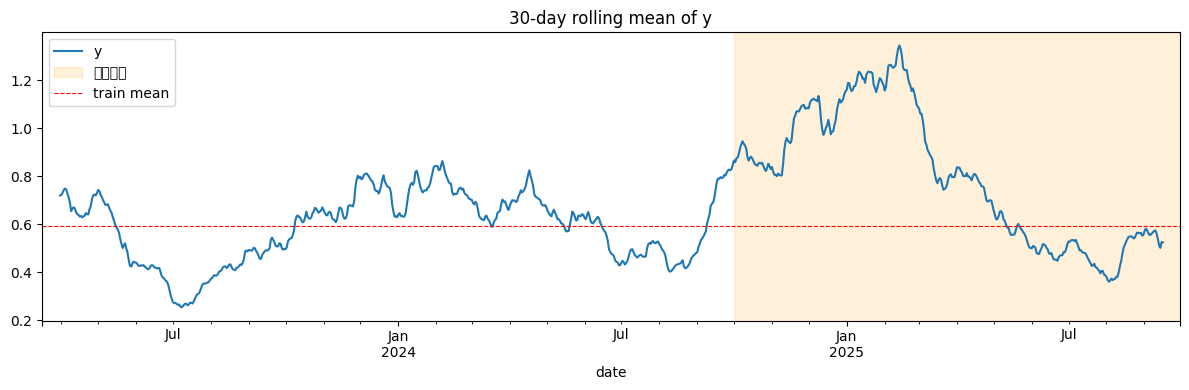

In [ ]:
# Compare the pseudo-evaluation period vs the training set, grouped by month
import matplotlib.pyplot as plt

train_by_month = y_train.groupby(y_train.index.month).mean()
eval_by_month = y_eval.groupby(y_eval.index.month).mean()

cmp = pd.DataFrame({"train_2023-24": train_by_month, "eval_2024-25": eval_by_month})
print(cmp)
print("\nMonthly mean difference (eval - train):")
print((cmp["eval_2024-25"] - cmp["train_2023-24"]).round(3))
print(f"\nOverall train mean: {y_train.mean():.3f}")
print(f"Overall pseudo-eval mean: {y_eval.mean():.3f}")

# 30-day rolling-mean plot
fig, ax = plt.subplots(figsize=(12, 4))
y.rolling(30, center=True).mean().plot(ax=ax)
ax.axvspan(EVAL_START, EVAL_END, alpha=0.15, color="orange", label="Pseudo-eval period")
ax.axhline(y_train.mean(), color="red", ls="--", lw=0.8, label="train mean")
ax.set_title("30-day rolling mean of y")
ax.legend()
plt.tight_layout()
plt.savefig("y_rolling.png", dpi=120)
plt.show()


=== A3 基线 ===
MXD + holiday + drift                MSE_1to5d = 0.0976   MSE_6to10d = 0.1106
MXD + monthly drift                  MSE_1to5d = 0.0926   MSE_6to10d = 0.1022
MXD + holiday + multi-drift          MSE_1to5d = 0.0930   MSE_6to10d = 0.1033
MXD + holiday (no drift)             MSE_1to5d = 0.1295   MSE_6to10d = 0.1295


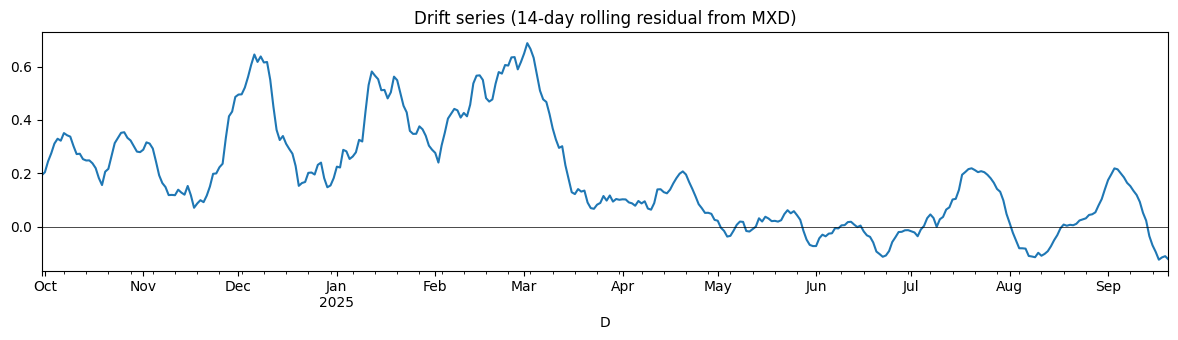


Drift 描述: mean=0.188, std=0.199
Drift 范围: [-0.124, 0.688]


In [ ]:
import holidays

# UK (England) public holidays
uk_holidays = holidays.UnitedKingdom(subdiv="ENG", years=range(2023, 2027))
HOLIDAY_DATES = set(pd.Timestamp(d) for d in uk_holidays.keys())

def is_holiday(d):
    return d.normalize() in HOLIDAY_DATES

def days_around_holiday(d, window=2):
    """Return the number of days between d and the nearest holiday (including sign), only if it is within ±window."""
    for offset in range(-window, window + 1):
        if (d + pd.Timedelta(days=offset)).normalize() in HOLIDAY_DATES:
            return offset
    return None

# === Baseline 6: MXD + holiday flag + drift ===
# Build a table on the training set: (month, dow, is_holiday) -> mean
def make_mxd_hol_table(y_series):
    df_ = pd.DataFrame({
        "y": y_series.values,
        "month": y_series.index.month,
        "dow": y_series.index.dayofweek,
        "hol": [is_holiday(d) for d in y_series.index],
    })
    return df_.groupby(["month", "dow", "hol"])["y"].mean()

MXD_HOL_TABLE = make_mxd_hol_table(y_train)
# Keep a pure MXD fallback for missing combinations
MXD_FALLBACK = y_train.groupby([y_train.index.month, y_train.index.dayofweek]).mean()

def mxd_hol_lookup(d):
    key = (d.month, d.dayofweek, is_holiday(d))
    if key in MXD_HOL_TABLE.index:
        return MXD_HOL_TABLE.loc[key]
    return MXD_FALLBACK.loc[(d.month, d.dayofweek)]

def fc_mxd_hol_drift(D, available_y):
    recent = available_y.iloc[-14:]
    if len(recent) == 0:
        drift = 0.0
    else:
        recent_pred = pd.Series([mxd_hol_lookup(d) for d in recent.index], index=recent.index)
        drift = (recent - recent_pred).mean()
    return np.array([mxd_hol_lookup(D + pd.Timedelta(days=h)) + drift for h in range(1, 11)])


# === Baseline 7: MXD + monthly drift (to let worsening winter conditions be captured locally) ===
# Compute drift separately by month, using the most recent 28 days with month-aware matching
def fc_mxd_monthly_drift(D, available_y):
    out = np.empty(10)
    # Global drift as a fallback
    recent_all = available_y.iloc[-14:]
    if len(recent_all) > 0:
        rp = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in recent_all.index],
                       index=recent_all.index)
        global_drift = (recent_all - rp).mean()
    else:
        global_drift = 0.0

    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        # Recent residuals from the same month (within the last 60 days and matching the target month)
        recent60 = available_y.iloc[-60:]
        same_month = recent60[recent60.index.month == d.month]
        if len(same_month) >= 3:
            sp = pd.Series([MXD_FALLBACK.loc[(dd.month, dd.dayofweek)] for dd in same_month.index],
                           index=same_month.index)
            month_drift = (same_month - sp).mean()
        else:
            month_drift = global_drift
        out[h - 1] = MXD_FALLBACK.loc[(d.month, d.dayofweek)] + month_drift
    return out


# === Baseline 8: MXD + holiday + adaptive drift window length ===
# Average the 7/14/28-day drift values to reduce the risk of relying on a single window length
def fc_mxd_hol_multidrift(D, available_y):
    drifts = []
    for window in [7, 14, 28]:
        rec = available_y.iloc[-window:]
        if len(rec) == 0:
            continue
        rp = pd.Series([mxd_hol_lookup(d) for d in rec.index], index=rec.index)
        drifts.append((rec - rp).mean())
    drift = np.mean(drifts) if drifts else 0.0
    return np.array([mxd_hol_lookup(D + pd.Timedelta(days=h)) + drift for h in range(1, 11)])


print("\n=== A3 baselines ===")
for name, fn in [
    ("MXD + holiday + drift", fc_mxd_hol_drift),
    ("MXD + monthly drift", fc_mxd_monthly_drift),
    ("MXD + holiday + multi-drift", fc_mxd_hol_multidrift),
]:
    evaluate_forecaster(fn, D_list, y, name)


# === Also run a pure holiday version to see how much holidays contribute on their own ===
def fc_mxd_hol_only(D, available_y):
    return np.array([mxd_hol_lookup(D + pd.Timedelta(days=h)) for h in range(1, 11)])

evaluate_forecaster(fc_mxd_hol_only, D_list, y, "MXD + holiday (no drift)")


# === Also inspect the drift series itself: is it stable? ===
import matplotlib.pyplot as plt
drift_series = []
for D in D_list:
    avail = make_available_y(y, D)
    rec = avail.iloc[-14:]
    rp = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in rec.index], index=rec.index)
    drift_series.append({"D": D, "drift": (rec - rp).mean()})
drift_df = pd.DataFrame(drift_series).set_index("D")

fig, ax = plt.subplots(figsize=(12, 3.5))
drift_df["drift"].plot(ax=ax)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Drift series (14-day rolling residual from MXD)")
plt.tight_layout()
plt.savefig("drift_series.png", dpi=120)
plt.show()
print(f"\nDrift summary: mean={drift_df['drift'].mean():.3f}, std={drift_df['drift'].std():.3f}")
print(f"Drift range: [{drift_df['drift'].min():.3f}, {drift_df['drift'].max():.3f}]")

训练集 holiday 残差均值 (加法调整): -0.2459
训练集 near-holiday (非节假日本身) 残差均值: 0.0051

=== A3.5 改进 ===
Monthly drift + hol adj              MSE_1to5d = 0.0906   MSE_6to10d = 0.1002
Monthly drift + hol + near-hol       MSE_1to5d = 0.0906   MSE_6to10d = 0.1002
Monthly drift (120d + decay)         MSE_1to5d = 0.0929   MSE_6to10d = 0.1035


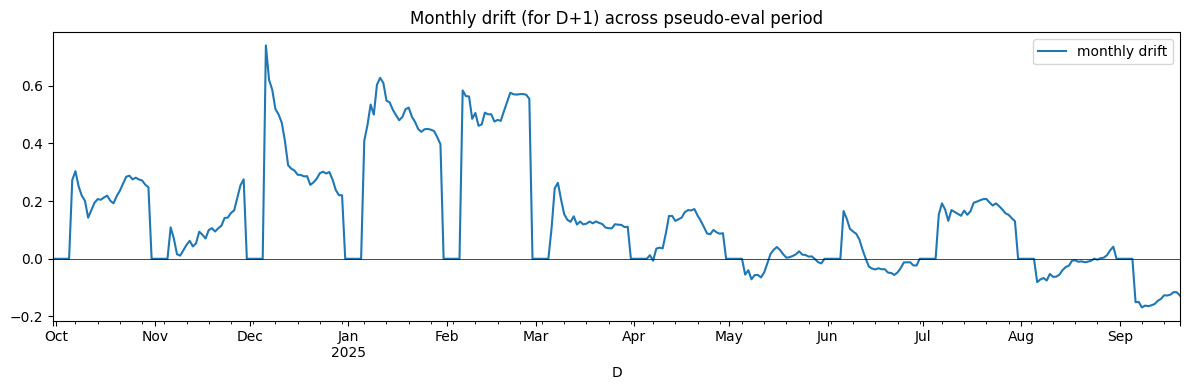


Monthly drift: mean=0.137, std=0.193


In [ ]:
# === Improvement 1: monthly drift + holiday adjustment (additive) ===
# Compute the mean residual on holidays in the training set as one shared additive term
def make_holiday_adjustment(y_series):
    pred = pd.Series(
        [MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in y_series.index],
        index=y_series.index,
    )
    resid = y_series - pred
    is_hol = pd.Series([is_holiday(d) for d in y_series.index], index=y_series.index)
    return resid[is_hol].mean()  # single scalar

HOLIDAY_ADJ = make_holiday_adjustment(y_train)
print(f"Training-set holiday mean residual (additive adjustment): {HOLIDAY_ADJ:.4f}")

def fc_monthly_drift_hol_adj(D, available_y):
    recent_all = available_y.iloc[-14:]
    if len(recent_all) > 0:
        rp = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in recent_all.index],
                       index=recent_all.index)
        global_drift = (recent_all - rp).mean()
    else:
        global_drift = 0.0

    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        recent60 = available_y.iloc[-60:]
        same_month = recent60[recent60.index.month == d.month]
        if len(same_month) >= 3:
            sp = pd.Series([MXD_FALLBACK.loc[(dd.month, dd.dayofweek)] for dd in same_month.index],
                           index=same_month.index)
            month_drift = (same_month - sp).mean()
        else:
            month_drift = global_drift
        base = MXD_FALLBACK.loc[(d.month, d.dayofweek)] + month_drift
        if is_holiday(d):
            base += HOLIDAY_ADJ
        out[h - 1] = base
    return out


# === Improvement 2: monthly drift + adjustment for days adjacent to holidays ===
# Days 1-2 before and after holidays are often abnormal as well
def days_near_holiday(d, window=2):
    for off in range(-window, window + 1):
        if (d + pd.Timedelta(days=off)).normalize() in HOLIDAY_DATES:
            return True
    return False

# Compute the mean residual for days near holidays (excluding the holiday itself)
def make_near_holiday_adj(y_series):
    pred = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in y_series.index],
                     index=y_series.index)
    resid = y_series - pred
    is_hol = pd.Series([is_holiday(d) for d in y_series.index], index=y_series.index)
    is_near = pd.Series([days_near_holiday(d, 2) for d in y_series.index], index=y_series.index)
    near_only = is_near & ~is_hol
    return resid[near_only].mean()

NEAR_HOL_ADJ = make_near_holiday_adj(y_train)
print(f"Training-set near-holiday mean residual (excluding the holiday itself): {NEAR_HOL_ADJ:.4f}")

def fc_monthly_drift_full_hol(D, available_y):
    recent_all = available_y.iloc[-14:]
    if len(recent_all) > 0:
        rp = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in recent_all.index],
                       index=recent_all.index)
        global_drift = (recent_all - rp).mean()
    else:
        global_drift = 0.0

    out = np.empty(10)
    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        recent60 = available_y.iloc[-60:]
        same_month = recent60[recent60.index.month == d.month]
        if len(same_month) >= 3:
            sp = pd.Series([MXD_FALLBACK.loc[(dd.month, dd.dayofweek)] for dd in same_month.index],
                           index=same_month.index)
            month_drift = (same_month - sp).mean()
        else:
            month_drift = global_drift
        base = MXD_FALLBACK.loc[(d.month, d.dayofweek)] + month_drift
        if is_holiday(d):
            base += HOLIDAY_ADJ
        elif days_near_holiday(d, 2):
            base += NEAR_HOL_ADJ
        out[h - 1] = base
    return out


# === Improvement 3: use a longer lookback for monthly drift, with same-month weighting ===
# The earlier version used same-month data within 60 days; here we switch to 120 days plus decay weights
def fc_monthly_drift_long(D, available_y):
    out = np.empty(10)
    recent_all = available_y.iloc[-14:]
    if len(recent_all) > 0:
        rp = pd.Series([MXD_FALLBACK.loc[(d.month, d.dayofweek)] for d in recent_all.index],
                       index=recent_all.index)
        global_drift = (recent_all - rp).mean()
    else:
        global_drift = 0.0

    for h in range(1, 11):
        d = D + pd.Timedelta(days=h)
        recent120 = available_y.iloc[-120:]
        same_month = recent120[recent120.index.month == d.month]
        if len(same_month) >= 5:
            sp = pd.Series([MXD_FALLBACK.loc[(dd.month, dd.dayofweek)] for dd in same_month.index],
                           index=same_month.index)
            resids = same_month - sp
            # Time-decay weights: more recent observations get larger weights
            days_back = (D - resids.index).days.astype(float)
            w = np.exp(-days_back / 30.0)  # 30-day half-life
            month_drift = np.average(resids.values, weights=w)
        else:
            month_drift = global_drift
        out[h - 1] = MXD_FALLBACK.loc[(d.month, d.dayofweek)] + month_drift
    return out


print("\n=== A3.5 improvements ===")
evaluate_forecaster(fc_monthly_drift_hol_adj, D_list, y, "Monthly drift + hol adj")
evaluate_forecaster(fc_monthly_drift_full_hol, D_list, y, "Monthly drift + hol + near-hol")
evaluate_forecaster(fc_monthly_drift_long, D_list, y, "Monthly drift (120d + decay)")


# === Also inspect what the drift time series looks like under the monthly version ===
import matplotlib.pyplot as plt

monthly_drift_series = []
for D in D_list:
    avail = make_available_y(y, D)
    d_test = D + pd.Timedelta(days=1)
    recent60 = avail.iloc[-60:]
    same_month = recent60[recent60.index.month == d_test.month]
    if len(same_month) >= 3:
        sp = pd.Series([MXD_FALLBACK.loc[(dd.month, dd.dayofweek)] for dd in same_month.index],
                       index=same_month.index)
        md = (same_month - sp).mean()
    else:
        md = 0.0
    monthly_drift_series.append({"D": D, "drift_for_D+1": md, "month_targeted": d_test.month})

mds = pd.DataFrame(monthly_drift_series).set_index("D")
fig, ax = plt.subplots(figsize=(12, 4))
mds["drift_for_D+1"].plot(ax=ax, label="monthly drift")
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Monthly drift (for D+1) across the pseudo-evaluation period")
ax.legend()
plt.tight_layout()
plt.savefig("monthly_drift.png", dpi=120)
plt.show()
print(f"\nMonthly drift: mean={mds['drift_for_D+1'].mean():.3f}, std={mds['drift_for_D+1'].std():.3f}")

总预测数: 3560
           D  horizon target_date      pred    actual
0 2024-09-30        1  2024-10-01  1.213006  1.490037
1 2024-09-30        2  2024-10-02  0.785489  1.023024
2 2024-09-30        3  2024-10-03  0.773582  0.501418
3 2024-09-30        4  2024-10-04  0.585280  0.788201
4 2024-09-30        5  2024-10-05  0.636500  0.485456


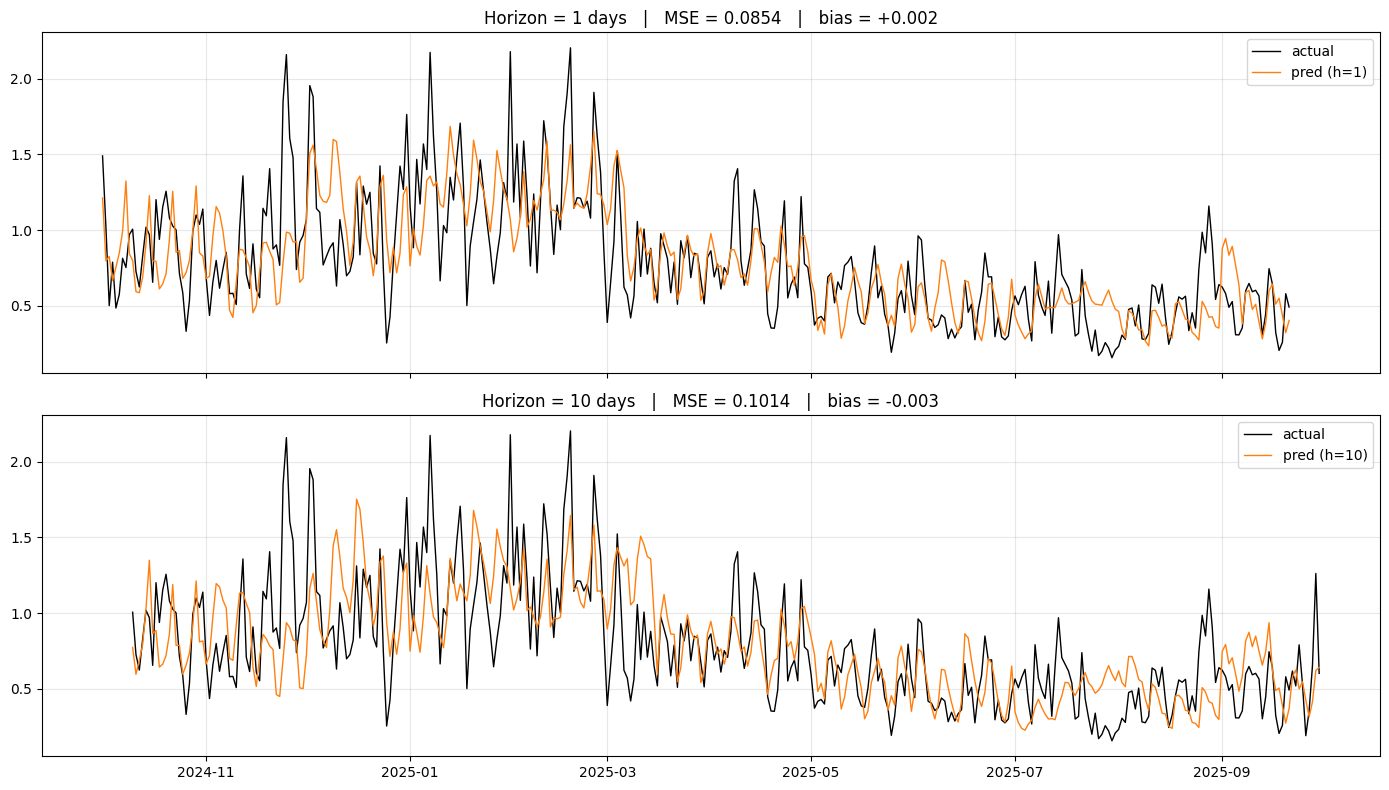

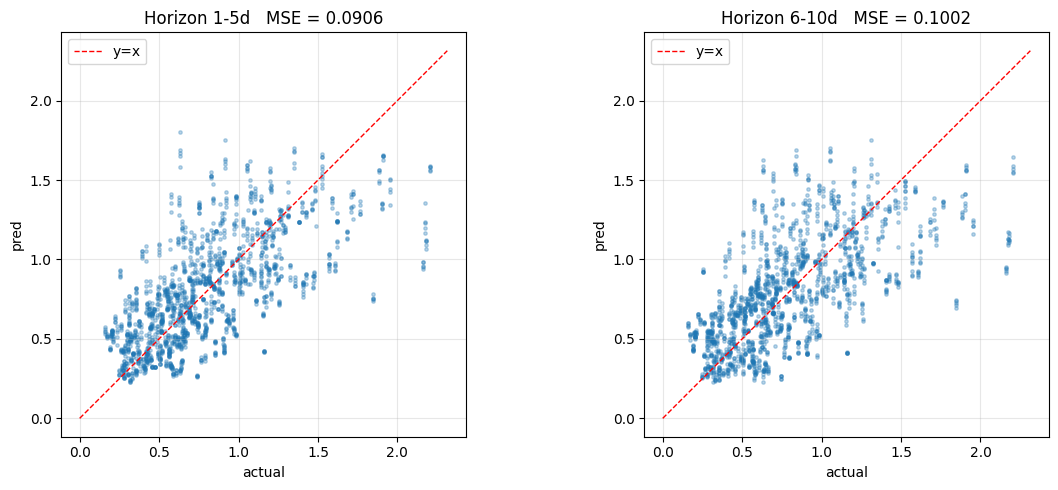

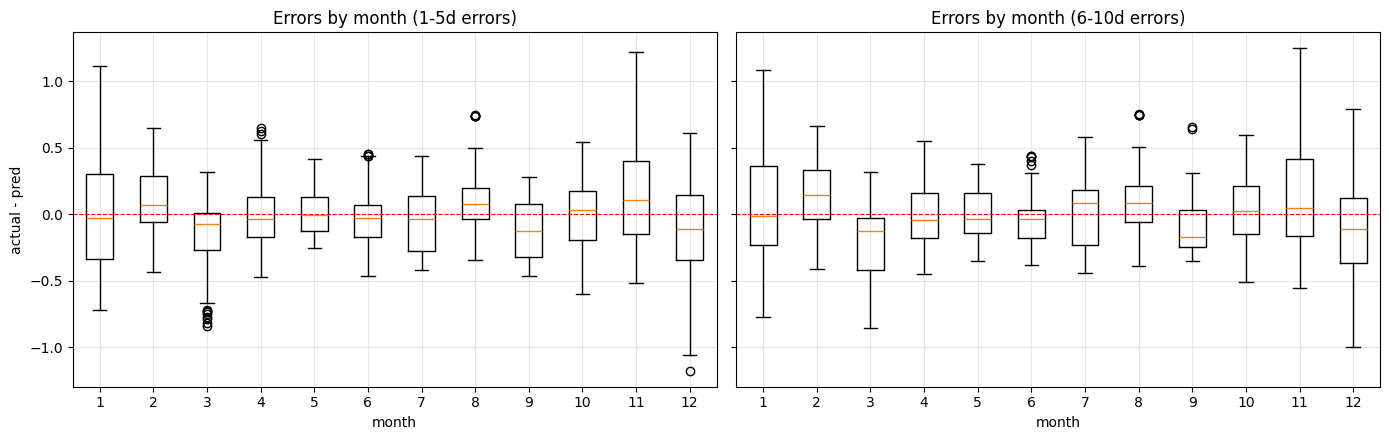


=== 1-5d 最差的 10 个预测 ===
target_date  horizon   actual     pred  abs_err
 2024-11-25        5 2.159445 0.938817 1.220628
 2024-11-25        4 2.159445 0.950223 1.209223
 2024-11-25        3 2.159445 0.959082 1.200363
 2024-12-10        4 0.630855 1.805446 1.174591
 2024-11-25        2 2.159445 0.985945 1.173500
 2024-11-25        1 2.159445 0.986945 1.172500
 2025-01-31        1 2.178512 1.068619 1.109894
 2024-11-24        4 1.847375 0.738295 1.109081
 2024-11-24        3 1.847375 0.749700 1.097675
 2024-11-24        5 1.847375 0.749837 1.097539

=== 6-10d 最差的 10 个预测 ===
target_date  horizon   actual     pred  abs_err
 2024-11-25        8 2.159445 0.914664 1.244781
 2024-11-25        9 2.159445 0.927617 1.231828
 2024-11-25       10 2.159445 0.938208 1.221238
 2024-11-25        7 2.159445 0.943902 1.215544
 2024-11-25        6 2.159445 0.950359 1.209086
 2024-11-24       10 1.847375 0.697319 1.150057
 2024-11-24        7 1.847375 0.714142 1.133233
 2024-11-24        8 1.847375 0.72709

In [ ]:
import matplotlib.pyplot as plt

# === Re-collect predictions from the best baseline, while keeping the (D, horizon, target_date, pred, actual) tuple ===
records = []
for D in D_list:
    avail = make_available_y(y, D)
    preds = fc_monthly_drift_hol_adj(D, avail)
    for h in range(1, 11):
        target_date = D + pd.Timedelta(days=h)
        if target_date in y.index:
            records.append({
                "D": D,
                "horizon": h,
                "target_date": target_date,
                "pred": preds[h - 1],
                "actual": y.loc[target_date],
            })

R = pd.DataFrame(records)
print(f"Total predictions: {len(R)}")
print(R.head())


# === Figure 1: for each target_date, compare the horizon=1 and horizon=10 forecasts against the truth ===
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, h in zip(axes, [1, 10]):
    sub = R[R["horizon"] == h].sort_values("target_date")
    ax.plot(sub["target_date"], sub["actual"], color="black", lw=1, label="actual")
    ax.plot(sub["target_date"], sub["pred"], color="C1", lw=1, label=f"pred (h={h})")
    err = sub["actual"] - sub["pred"]
    mse = (err ** 2).mean()
    ax.set_title(f"Horizon = {h} days   |   MSE = {mse:.4f}   |   bias = {err.mean():+.3f}")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=120)
plt.show()


# === Figure 2: scatter plot (pred vs actual), split into 1-5d and 6-10d ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, mask) in zip(axes, [
    ("Horizon 1-5d", R["horizon"] <= 5),
    ("Horizon 6-10d", R["horizon"] >= 6),
]):
    sub = R[mask]
    ax.scatter(sub["actual"], sub["pred"], s=6, alpha=0.3)
    lim = [0, max(sub["actual"].max(), sub["pred"].max()) * 1.05]
    ax.plot(lim, lim, "r--", lw=1, label="y=x")
    ax.set_xlabel("actual")
    ax.set_ylabel("pred")
    ax.set_title(f"{label}   MSE = {((sub['actual']-sub['pred'])**2).mean():.4f}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("pred_vs_actual_scatter.png", dpi=120)
plt.show()


# === Figure 3: boxplots of error grouped by month ===
R["target_month"] = R["target_date"].dt.month
R["error"] = R["actual"] - R["pred"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (label, mask) in zip(axes, [
    ("1-5d errors", R["horizon"] <= 5),
    ("6-10d errors", R["horizon"] >= 6),
]):
    sub = R[mask]
    data = [sub.loc[sub["target_month"] == m, "error"].values for m in range(1, 13)]
    ax.boxplot(data, tick_labels=range(1, 13))
    ax.axhline(0, color="red", ls="--", lw=0.8)
    ax.set_xlabel("month")
    ax.set_title(f"Errors by month ({label})")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("actual - pred")
plt.tight_layout()
plt.savefig("error_by_month.png", dpi=120)
plt.show()


# === Table 1: worst 10 days ===
print("\n=== Worst 10 forecasts for 1-5d ===")
worst_15 = R[R["horizon"] <= 5].assign(abs_err=lambda d: (d["actual"] - d["pred"]).abs()) \
    .sort_values("abs_err", ascending=False).head(10)
print(worst_15[["target_date", "horizon", "actual", "pred", "abs_err"]].to_string(index=False))

print("\n=== Worst 10 forecasts for 6-10d ===")
worst_610 = R[R["horizon"] >= 6].assign(abs_err=lambda d: (d["actual"] - d["pred"]).abs()) \
    .sort_values("abs_err", ascending=False).head(10)
print(worst_610[["target_date", "horizon", "actual", "pred", "abs_err"]].to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np

# Reload the long-format data (assuming df is still in the namespace)
# If not, load it from the raw file:
# df = pd.read_csv("data/development_dataset.csv")
# df["dt"] = pd.to_datetime(df["dt"], format="ISO8601")

# Keep only features
feat = df[df["variable_type"] == "feature"].copy()

# Build a health-check table for each (metric, coverage) combination
print("Summarizing each variable combination...")

summary = (
    feat.groupby(["metric_name", "coverage"])
    .agg(
        n_rows=("value", "size"),
        n_non_null=("value", lambda x: x.notna().sum()),
        first_dt=("dt", "min"),
        last_dt=("dt", "max"),
        val_mean=("value", "mean"),
        val_std=("value", "std"),
        val_min=("value", "min"),
        val_max=("value", "max"),
        n_unique=("value", "nunique"),
    )
    .reset_index()
)

# Add a few derived columns
summary["span_days"] = (summary["last_dt"] - summary["first_dt"]).dt.total_seconds() / 86400
summary["rows_per_day"] = summary["n_rows"] / summary["span_days"].clip(lower=1)
summary["inferred_freq"] = pd.cut(
    summary["rows_per_day"],
    bins=[0, 1.5, 8, 30, 200],
    labels=["daily_or_less", "few_per_day", "hourly_ish", "15min"],
)
summary["last_dt_date"] = summary["last_dt"].dt.date

print(f"Total combinations: {len(summary)}")
print("\nGrouped by inferred frequency:")
print(summary["inferred_freq"].value_counts())

# Inspect the end-date distribution — this shows which variables have no data in the evaluation period
print("\nGrouped by last_dt month (evaluation period = after 2025-10):")
print(summary["last_dt"].dt.to_period("M").value_counts().sort_index().tail(10))

# Identify variables with last_dt before 2025-09 — unavailable in the evaluation period!
EVAL_START = pd.Timestamp("2025-10-01")
TRAIN_END = pd.Timestamp("2025-09-30")
covers_eval = summary["last_dt"] >= EVAL_START
print(f"\nNumber of combinations with last_dt >= 2025-10-01: {covers_eval.sum()} / {len(summary)}")
print(f"That means the number of combinations unavailable in the formal evaluation period is: {(~covers_eval).sum()}")

# Inspect the last_dt distribution of these evaluation-unavailable variables
print("\nDistribution of last_dt for combinations unavailable in the evaluation period:")
print(summary.loc[~covers_eval, "last_dt"].dt.to_period("M").value_counts().sort_index())

# Save the full table for reference
summary.to_csv("variable_summary.csv", index=False)
print("\nSaved variable_summary.csv")

# Print a few key slices
print("\n=== Frequency distribution details ===")
for freq in summary["inferred_freq"].cat.categories:
    sub = summary[summary["inferred_freq"] == freq]
    print(f"\n[{freq}] n={len(sub)}, {(sub['last_dt'] >= EVAL_START).sum()} cover the evaluation period")
    print(f"  Example metrics: {sub['metric_name'].drop_duplicates().head(5).tolist()}")

正在汇总每个变量组合的信息...
总组合数: 559

按推断频率分组:
inferred_freq
daily_or_less    239
15min            172
hourly_ish       147
few_per_day        1
Name: count, dtype: int64

按 last_dt 月份分组（评估期 = 2025-10 之后）:
last_dt
2025-05      1
2025-08      1
2025-09    337
2026-03    220
Freq: M, Name: count, dtype: int64

last_dt >= 2025-10-01 的组合数: 220 / 559
也就是说，正式评估期不可用的组合数: 339

评估期不可用的组合 last_dt 分布:
last_dt
2025-05      1
2025-08      1
2025-09    337
Freq: M, Name: count, dtype: int64

已保存 variable_summary.csv

=== 频率分布详情 ===

[daily_or_less] n=239, 覆盖评估期的有 0 个
  示例 metric: ['% of beds occupied by patients with NCtR', '% of patients spending >12 hours in ED', 'A&E attends - paediatrics', 'Aggregated NHSE OPEL Score', 'Automated OPEL']

[few_per_day] n=1, 覆盖评估期的有 0 个
  示例 metric: ['No. of DTAs (> 8hrs)']

[hourly_ish] n=147, 覆盖评估期的有 144 个
  示例 metric: ['(SWASFT) Number of HCP Incidents', '(SWASFT) Number of NHS 111 Incidents', '(Severnside) CAS Referred to ED', '(Severnside) Calls Answered', '(Severnside